In [1]:
import pandas as pd

train = pd.read_pickle("../data/train.pkl")
test = pd.read_pickle("../data/test.pkl")

train.head()


,user,item,rating
38240,1440,39757,1
3806,5297,42139,4
27927,2712,78915,5
6006,9949,77259,5
65809,5741,72446,5


In [2]:
import numpy as np
import random

class UserBanditEnv:
    def __init__(self, df):
        self.df = df
        self.user_groups = df.groupby("user")

    def sample_user(self):
        return random.choice(list(self.user_groups.groups.keys()))

    def get_user_data(self, user):
        return self.user_groups.get_group(user)



In [3]:
class EpsilonGreedy:
    def __init__(self, n_items, epsilon=0.1):
        self.n_items = n_items
        self.epsilon = epsilon
        self.counts = np.zeros(n_items)
        self.values = np.zeros(n_items)

    def select_item(self):
        if random.random() < self.epsilon:
            return random.randint(0, self.n_items - 1)
        else:
            return np.argmax(self.values)

    def update(self, item, reward):
        self.counts[item] += 1
        n = self.counts[item]
        value = self.values[item]
        self.values[item] = value + (reward - value) / n


In [4]:
class UCB1:
    def __init__(self, n_items):
        self.n_items = n_items
        self.counts = np.zeros(n_items)
        self.values = np.zeros(n_items)
        self.total_count = 0

    def select_item(self):
        self.total_count += 1

        ucb_scores = self.values + np.sqrt(2 * np.log(self.total_count + 1) /
                                           (self.counts + 1e-6))
        return np.argmax(ucb_scores)

    def update(self, item, reward):
        self.counts[item] += 1
        n = self.counts[item]
        value = self.values[item]
        self.values[item] = value + (reward - value) / n


In [5]:
class ThompsonSampling:
    def __init__(self, n_items):
        self.n_items = n_items
        self.alpha = np.ones(n_items)
        self.beta = np.ones(n_items)

    def select_item(self):
        theta = np.random.beta(self.alpha, self.beta)
        return np.argmax(theta)

    def update(self, item, reward):
        self.alpha[item] += reward
        self.beta[item] += (5 - reward)  # rating max=5


In [6]:
def run_agent(agent, env, episodes=5000):
    rewards = []

    for _ in range(episodes):
        user = env.sample_user()
        dfu = env.get_user_data(user)

        row = dfu.sample(1).iloc[0]
        item = row["item"]
        reward = row["rating"]

        chosen = agent.select_item()
        agent.update(chosen, reward)

        rewards.append(reward)

    return rewards


In [7]:
env = UserBanditEnv(train)
n_items = train["item"].nunique()


In [15]:
eg_agent = EpsilonGreedy(n_items, epsilon=0.1)
rewards_eg = run_agent(eg_agent, env)
pd.to_pickle(rewards_eg, "../results/rewards_eg.pkl")


In [16]:
ucb_agent = UCB1(n_items)
rewards_ucb = run_agent(ucb_agent, env)
pd.to_pickle(rewards_ucb, "../results/rewards_ucb.pkl")


In [17]:
ts_agent = ThompsonSampling(n_items)
rewards_ts = run_agent(ts_agent, env)
pd.to_pickle(rewards_ts, "../results/rewards_ts.pkl")


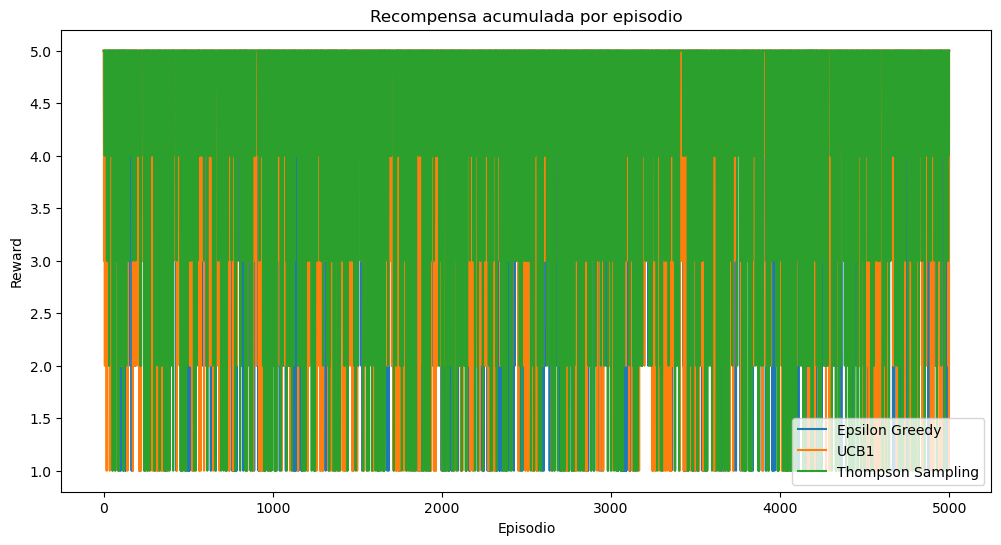

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(rewards_eg, label="Epsilon Greedy")
plt.plot(rewards_ucb, label="UCB1")
plt.plot(rewards_ts, label="Thompson Sampling")
plt.legend()
plt.title("Recompensa acumulada por episodio")
plt.xlabel("Episodio")
plt.ylabel("Reward")
plt.show()



In [24]:
import numpy as np

print("Epsilon Greedy:", np.mean(rewards_eg))
print("UCB1:", np.mean(rewards_ucb))
print("Thompson:", np.mean(rewards_ts))


Epsilon Greedy: 4.4474
UCB1: 4.4494
Thompson: 4.4598
